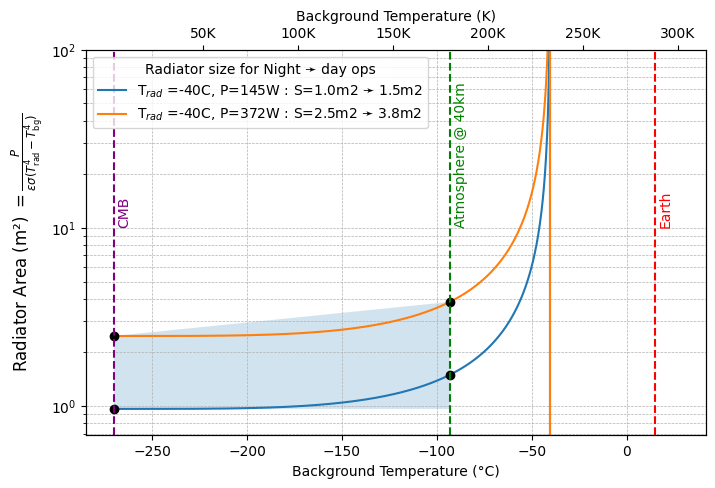

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt


P=145
def compute_radiator_surface_area(T_background, P=P, epsilon=0.9, T_radiator=250):
    """
    Compute the required radiator surface area.

    Parameters:
    - T_background: Background temperature array (K)
    - P: Power to dissipate (W)
    - epsilon: Emissivity of the radiator
    - T_radiator: Assumed radiator temperature (K)

    Returns:
    - A_radiator: Required radiator surface area array (m²)
    """
    sigma = 5.67e-8  # Stefan-Boltzmann constant (W/m²K⁴)
    return P / (epsilon * sigma * (T_radiator**4 - T_background**4))

# Compute required radiator surface area using the function
T_background = np.linspace(3, 300, 1000)  # Background temperature range (K)

# Key reference temperatures
T_earth = 288  # Earth's surface temperature (K)
T_atm_40km = 180  # Estimated atmospheric temperature at 40 km (K)
T_CMB = 3  # Cosmic Microwave Background (K)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot radiator surface area for different radiator temperatures
for T_radiator,P in zip([233,233],[145,372]):
    ax1.plot(T_background-273.15, compute_radiator_surface_area(T_background,P=P, T_radiator=T_radiator), 
             label=r"T$_{rad}$ =%iC, P=%iW : S=%0.1fm2 ➛ %0.1fm2"%(int(T_radiator-273.15),P,compute_radiator_surface_area(3, P=P,T_radiator=T_radiator),compute_radiator_surface_area(180, P=P,T_radiator=T_radiator)))
    plt.plot(3-273.15,compute_radiator_surface_area(3,P=P, T_radiator=T_radiator),"ko")
    plt.plot(180-273.15,compute_radiator_surface_area(180,P=P, T_radiator=T_radiator),"ko")
ax1.fill_between([3-273.15,180-273.15],[compute_radiator_surface_area(3, T_radiator=233,P=145),compute_radiator_surface_area(3, T_radiator=233,P=145)], [compute_radiator_surface_area(3, T_radiator=233,P=372),compute_radiator_surface_area(180, T_radiator=233,P=372)],alpha=0.2)

ax1.set_xlabel("Background Temperature (°C)")
ax1.set_ylabel(r"Radiator Area (m²) $= \frac{%s}{   \epsilon \sigma (T_{\text{rad}}^4 - T_{\text{bg}}^4)}$"%("P"),fontsize=12)
ax1.set_yscale("log")  # Log scale for better visibility
ax1.grid(True, which="both", linestyle="--", linewidth=0.5)

# Add secondary x-axis for Kelvin scale (at the top)
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
kelvin_ticks = [50, 100, 150, 200, 250, 300]
ax2.set_xticks([T - 273.15 for T in kelvin_ticks])  # Convert to Celsius scale
ax2.set_xticklabels([f"{T}K" for T in kelvin_ticks])
ax2.set_xlabel("Background Temperature (K)")

# Add vertical lines with inline text labels
for temp, label, color in zip([T_earth, T_atm_40km, T_CMB],
                               ["Earth", "Atmosphere @ 40km", "CMB"],
                               ['r', 'g', 'purple']):
    ax1.axvline(temp - 273.15, linestyle="--", color=color)  # Convert to Celsius
    ax1.text(temp - 273.15 + 2, 10, label, color=color, rotation=90, verticalalignment='bottom')

# Legend
ax1.legend(title="Radiator size for Night ➛ day ops")

ax1.set_ylim(ymax=100)
# Show plot
plt.show()

# javier
# black facing
#   maybe double it with fans


In [18]:
# Re-import necessary library after execution state reset
import numpy as np

# Given values
diameter_cm = 25  # Diameter of the cylinder in cm
radius_cm = diameter_cm / 2  # Radius in cm
volume_liters = 2.81  # Volume in liters
volume_cm3 = volume_liters * 1000  # Convert liters to cubic cm

# Calculate height using volume formula for a cylinder: V = πr²h
height_cm = volume_cm3 / (np.pi * radius_cm**2)
height_cm

5.724484993129291